<a href="https://colab.research.google.com/github/mnabi-paxai/LLM-Finetuning/blob/main/non_instruction_pretrain_llm_finetuning_on_domain_specific_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Non-instruction Finetuning

[Main Github](https://github.com/sunnysavita10/Complete-LLM-Finetuning/tree/main/LLM%20Fine-Tuning-14-Train-LLMs-on-Your-PDF-Text-Data%20-Domain-Specific-Fine-Tuning-with-HuggingFace)

## Full Finetuning

### Let's install the packages

In [ ]:
!pip install -U peft bitsandbytes transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 51.7 MB/s eta 0:00:00


In [ ]:
!pip install -U trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.6/992.6 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 43.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
!pip install -U PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 78.8 MB/s eta 0:00:00


### Prebuilt data from huggifface data hub



In [ ]:
from datasets import load_dataset, Dataset

In [ ]:
dataset = load_dataset("roneneldan/TinyStories", split="train")

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/train-00003-of-00004-d243063613e5a0(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [ ]:
print(dataset)

Dataset({
    features: ['text'],
    num_rows: 2119719
})


In [ ]:
print(dataset[0])

{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}


### Load our data (PDF format)

In [ ]:
import fitz

In [ ]:
import pymupdf

In [ ]:
def extract_text_from_pdf(pdf_path):
    text_blocks = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
          text = page.get_text("text").strip()
          if text:
            text_blocks.append(text)
    return text_blocks

In [ ]:
pdf_texts = extract_text_from_pdf("Metformin.pdf")

In [ ]:
pdf_texts

["Educational practice reference\nPage 1\nRL Practice Knowledge Sheet\nMetformin\nCore action. Metformin primarily lowers blood glucose by reducing hepatic glucose production, especially\ngluconeogenesis. Its molecular effects include changes in mitochondrial energy metabolism and cellular AMP/ATP\nbalance; activation of AMP-activated protein kinase (AMPK) contributes to several downstream metabolic effects, although\nmetformin's full mechanism is broader than AMPK alone.\nMetabolic effects. Reduced hepatic glucose output lowers fasting glucose. Metformin also improves insulin sensitivity in\nperipheral tissues and can modestly increase glucose uptake. Unlike insulin or sulfonylureas, it usually does not cause\nhypoglycemia when used by itself because it does not directly stimulate insulin secretion.\nCommon clinical advantages. Metformin is widely used as a first-line therapy for type 2 diabetes. It is generally\nweight-neutral or associated with modest weight loss, is inexpensive, an

In [ ]:
import re
def split_paragraphs(pages):
    paragraphs = []
    for page_text in pages:
        # Split on whitespace and at least two newlines
        chunks = re.split(r'\n+', page_text)
        for chunk in chunks:
            clean = chunk.strip()
            if len(clean) > 30:  # ignore too short lines
                paragraphs.append(clean)
    return paragraphs

In [ ]:
paragraphs = split_paragraphs(pdf_texts)

In [ ]:
paragraphs

['Core action. Metformin primarily lowers blood glucose by reducing hepatic glucose production, especially',
 'gluconeogenesis. Its molecular effects include changes in mitochondrial energy metabolism and cellular AMP/ATP',
 'balance; activation of AMP-activated protein kinase (AMPK) contributes to several downstream metabolic effects, although',
 "metformin's full mechanism is broader than AMPK alone.",
 'Metabolic effects. Reduced hepatic glucose output lowers fasting glucose. Metformin also improves insulin sensitivity in',
 'peripheral tissues and can modestly increase glucose uptake. Unlike insulin or sulfonylureas, it usually does not cause',
 'hypoglycemia when used by itself because it does not directly stimulate insulin secretion.',
 'Common clinical advantages. Metformin is widely used as a first-line therapy for type 2 diabetes. It is generally',
 'weight-neutral or associated with modest weight loss, is inexpensive, and has extensive long-term clinical experience.',
 'Gastr

In [ ]:
data = [{"text": p} for p in paragraphs]

In [ ]:
print(data)

[{'text': 'Core action. Metformin primarily lowers blood glucose by reducing hepatic glucose production, especially'}, {'text': 'gluconeogenesis. Its molecular effects include changes in mitochondrial energy metabolism and cellular AMP/ATP'}, {'text': 'balance; activation of AMP-activated protein kinase (AMPK) contributes to several downstream metabolic effects, although'}, {'text': "metformin's full mechanism is broader than AMPK alone."}, {'text': 'Metabolic effects. Reduced hepatic glucose output lowers fasting glucose. Metformin also improves insulin sensitivity in'}, {'text': 'peripheral tissues and can modestly increase glucose uptake. Unlike insulin or sulfonylureas, it usually does not cause'}, {'text': 'hypoglycemia when used by itself because it does not directly stimulate insulin secretion.'}, {'text': 'Common clinical advantages. Metformin is widely used as a first-line therapy for type 2 diabetes. It is generally'}, {'text': 'weight-neutral or associated with modest weight

### Now convert it to Huggingface data format

In [ ]:
dataset = Dataset.from_list(data)

In [ ]:
dataset

Dataset({
    features: ['text'],
    num_rows: 54
})

In [ ]:
dataset[0]

{'text': 'Core action. Metformin primarily lowers blood glucose by reducing hepatic glucose production, especially'}

### Let's select the *model*

In [ ]:
#model_name = "meta-llama/Llama-2-7b-hf"
# model_name = "meta-llama/Llama-3.1-8B"
model_name = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling

### Define the tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

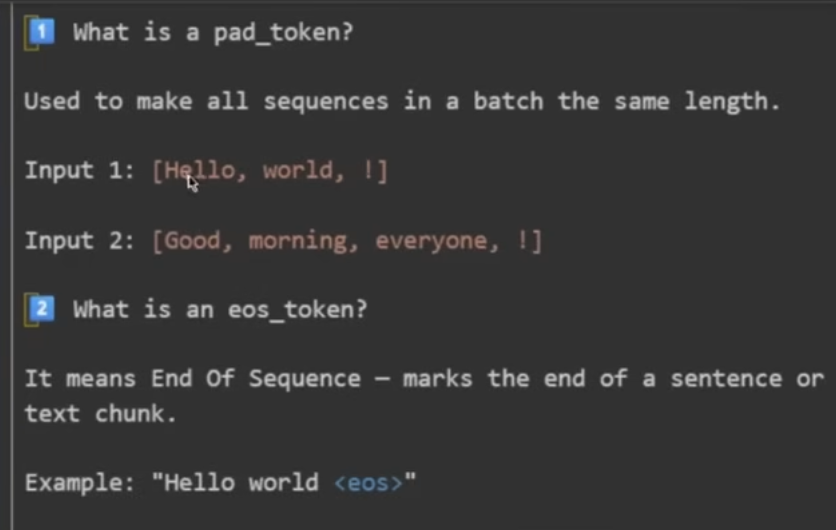

In [ ]:
def tokenize_fc(examples):
  tokens = tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)
  tokens["labels"] = tokens["input_ids"].copy()
  return tokens

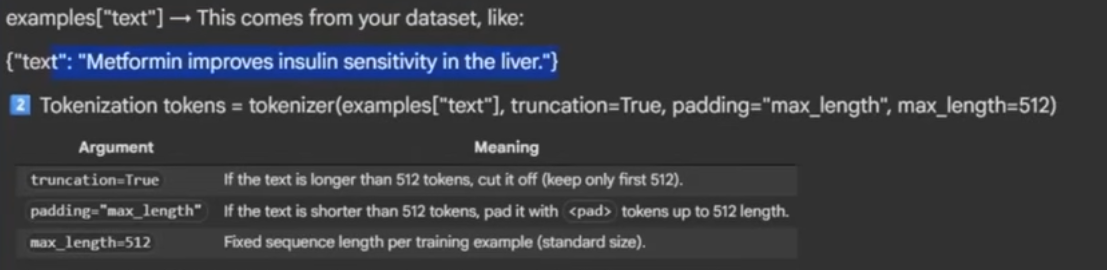

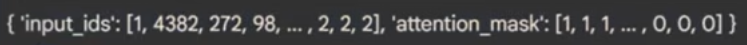

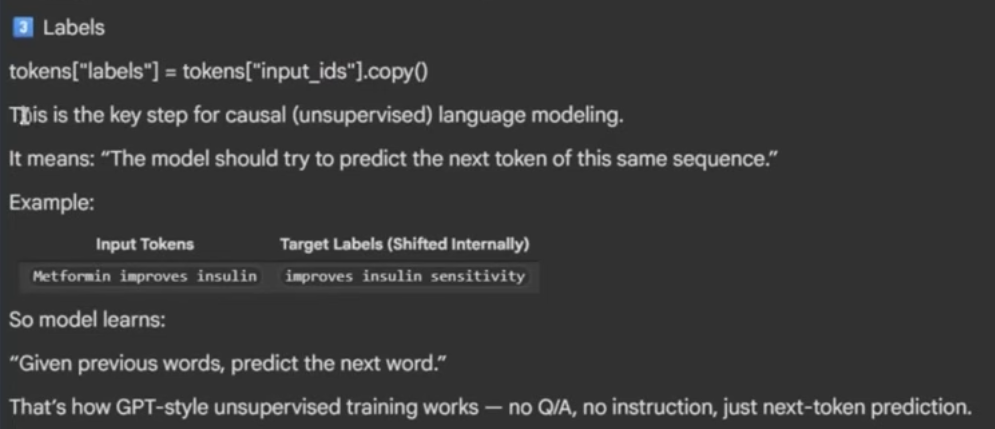

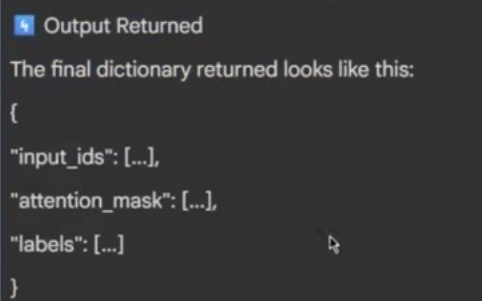

In [ ]:
tokenized = dataset.map(tokenize_fc, batched=True, remove_columns=["text"])

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

In [ ]:
tokenized

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 54
})

### Model training

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name)

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.40GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

In [ ]:
training_args = TrainingArguments(
    output_dir="./llama-pharma-domain",
    #overwrite_output_dir=True,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    learning_rate=2e-5,
    fp16=True,
    report_to="none"
)

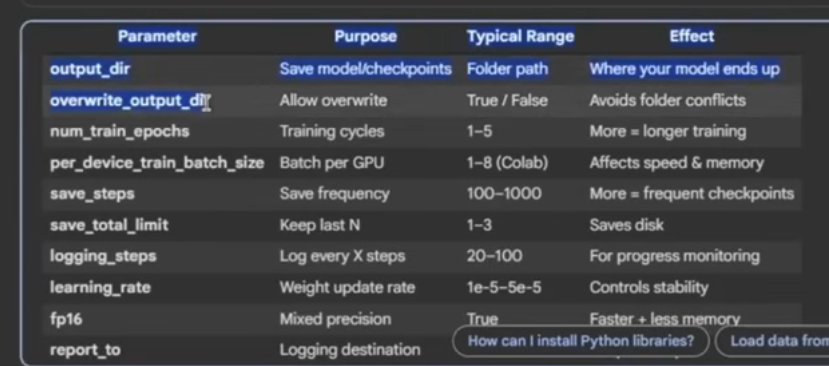

In [ ]:
from transformers import TrainingArguments
help(TrainingArguments)

Help on class TrainingArguments in module transformers.training_args:

class TrainingArguments(builtins.object)
 |  TrainingArguments(
 |      output_dir: str | None = None,
 |      per_device_train_batch_size: int = 8,
 |      num_train_epochs: float = 3.0,
 |      max_steps: int = -1,
 |      learning_rate: float = 5e-05,
 |      lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear',
 |      lr_scheduler_kwargs: dict | str | None = None,
 |      warmup_steps: float = 0,
 |      optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused',
 |      optim_args: str | None = None,
 |      weight_decay: float = 0.0,
 |      adam_beta1: float = 0.9,
 |      adam_beta2: float = 0.999,
 |      adam_epsilon: float = 1e-08,
 |      optim_target_modules: None | str | list[str] = None,
 |      gradient_accumulation_steps: int = 1,
 |      average_tokens_across_devices: bool = True,
 |      max_grad_norm: float = 1.0,
 |      label_smoothing_factor: float = 

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized
)

In [ ]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.292361


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=54, training_loss=0.27525257181238244, metrics={'train_runtime': 1924.406, 'train_samples_per_second': 0.056, 'train_steps_per_second': 0.028, 'total_flos': 343226380713984.0, 'train_loss': 0.27525257181238244, 'epoch': 2.0})

# Partial Finetuning

## Freeze some layers and update weights for the unfreezed layers

https://github.com/sunnysavita10/Complete-LLM-Finetuning/tree/main/LLM%20Fine-Tuning-09-Bert-finetuning

## LoRA - Low Rank Adaptation for LLMs

Remvoe Cache and extra memory

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

### Update the library

In [ ]:
!pip install -U peft bitsandbytes transformers accelerate tr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 MB 43.6 MB/s eta 0:00:00


In [ ]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 7.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

### Clean up data set - reading PDF, Chunking

In [ ]:
!pip install -U PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 107.8 MB/s eta 0:00:00


In [ ]:
from datasets import Dataset, load_dataset

In [ ]:
import pymupdf

In [ ]:
import fitz

In [ ]:
def extract_text_from_pdf(pdf_path):
    text_blocks = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
          text = page.get_text("text").strip()
          if text:
            text_blocks.append(text)
    return text_blocks

In [ ]:
pdf_texts = extract_text_from_pdf("Metformin.pdf")

In [ ]:
import re
def split_paragraphs(pages):
    paragraphs = []
    for page_text in pages:
        # Split on whitespace and at least two newlines
        chunks = re.split(r'\n+', page_text)
        for chunk in chunks:
            clean = chunk.strip()
            if len(clean) > 30:  # ignore too short lines
                paragraphs.append(clean)
    return paragraphs

In [ ]:
paragraphs = split_paragraphs(pdf_texts)

In [ ]:
data = [{"text": p} for p in paragraphs]

In [ ]:
dataset = Dataset.from_list(data)

### Select model

#### Log into HF

In [ ]:
from huggingface_hub import login

login()

In [ ]:
# model_name = "meta-llama/Llama-2-7b-hf"
# model_name = "meta-llama/Llama-3.1-8B"
# model_name = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
model_name = "meta-llama/Llama-3.2-1B"

### Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
def tokenize_fc(examples):
  tokens = tokenizer(
      examples["text"],
      truncations=True,
      padding="max_length",
      max_length=512
  )
  tokens["labels"] = tokens["input_ids"].copy()
  return tokens

In [ ]:
tokenized = dataset.map(tokenize_fc, batched=True, remove_columns=["text"])

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

In [ ]:
tokenized

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 54
})

### Load the model

In [ ]:
!pip install -U bitsandbytes

In [ ]:
from transformers import BitsAndBytesConfig
quantization_config = BitsAndBytesConfig(
    load_in_8bit=True
)
# loaded the quantized model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

### Define LoRA configuration

In [ ]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

In [ ]:
q_lora_model = get_peft_model(model, lora_config)

### Training arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./llama-pharma-domain",
    #overwrite_output_dir=True,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    learning_rate=2e-5,
    fp16=True,
    report_to="none"
)

# Code to download the trained model
!zip -r /content/llama-pharma-domain_checkpoint-54.zip ./llama-pharma-domain/checkpoint-54
from google.colab import files
files.download('/content/llama-pharma-domain_checkpoint-54.zip')

### Define the trainer

In [ ]:
trainer = Trainer(
    model=q_lora_model,
    args=training_args,
    train_dataset=tokenized
)

### Now Train

In [ ]:
trainer.train()

Step,Training Loss
50,5.841081


TrainOutput(global_step=54, training_loss=5.7801927637170865, metrics={'train_runtime': 19.3265, 'train_samples_per_second': 5.588, 'train_steps_per_second': 2.794, 'total_flos': 323149186990080.0, 'train_loss': 5.7801927637170865, 'epoch': 2.0})

### Loading the trained (finetuned) model

In [ ]:
model_path = "llama-pharma-domain/checkpoint-54"

In [ ]:
!pip install -U torchao

In [ ]:
!pip install -U peft bitsandbytes transformers accelerate tr

In [ ]:
trained_model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto"
)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

### Testing the model

In [ ]:
prompt = 'Explain why combining atorvastatin with ezetimibe can lower LDL cholesterol more effectively than increasing the dose of atorvastatin alone. Describe the mechanism of action of each drug and explain why their effects are complementary.'

In [ ]:
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [ ]:
inputs

{'input_ids': tensor([[128000,    849,  21435,   3249,  35271,    520,    269,     85,    561,
          15111,    449,  44420, 102873,  24459,    649,   4827,  86543,  39086,
            810,  13750,   1109,   7859,    279,  19660,    315,    520,    269,
             85,    561,  15111,   7636,     13,  61885,    279,  17383,    315,
           1957,    315,   1855,   5623,    323,  10552,   3249,    872,   6372,
            527,  58535,     13]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}

In [ ]:
outputs = trained_model.generate(
    **inputs,
    max_new_tokens=200,
    do_sample=True,
    temperature=0.8,
    top_p=0.9
    #repitition_penalty=1.1
)

In [ ]:
outputs

tensor([[128000,    849,  21435,   3249,  35271,    520,    269,     85,    561,
          15111,    449,  44420, 102873,  24459,    649,   4827,  86543,  39086,
            810,  13750,   1109,   7859,    279,  19660,    315,    520,    269,
             85,    561,  15111,   7636,     13,  61885,    279,  17383,    315,
           1957,    315,   1855,   5623,    323,  10552,   3249,    872,   6372,
            527,  58535,     13,  83017,   1268,    279,  10824,    315,   1521,
           1403,  11217,    649,    387,   1511,    311,   8108,  86543,  39086,
            323,   7417,  14830,  20124,    627,    791,   4495,   4320,    374,
            356,     13,    578,  10824,    315,   1521,   1403,  11217,    649,
            387,   1511,    311,   8108,  86543,  39086,    323,   7417,  14830,
          20124,     13,   2468,    269,     85,    561,  15111,    374,    264,
           2863,    258,     11,    902,  20747,   1220,    473,  33039,  87271,
             32,    312,   1

In [ ]:
decoded_outputs = tokenizer.decode(outputs[0], skip_special_tokens=True)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


In [ ]:
decoded_outputs

'Explain why combining atorvastatin with ezetimibe can lower LDL cholesterol more effectively than increasing the dose of atorvastatin alone. Describe the mechanism of action of each drug and explain why their effects are complementary. Explain how the combination of these two drugs can be used to reduce LDL cholesterol and improve clinical outcomes.\nThe correct answer is C. The combination of these two drugs can be used to reduce LDL cholesterol and improve clinical outcomes. Atorvastatin is a statin, which inhibits HMG-CoA reductase. This enzyme catalyzes the first and rate-limiting step in the cholesterol synthesis pathway. The formation of cholesterol involves the formation of mevalonate, which is a precursor of cholesterol. Ezetimibe is a cholesterol absorption inhibitor. It prevents the absorption of cholesterol from the gut and reduces LDL cholesterol. Ezetimibe acts by inhibiting the absorption of cholesterol from the intestine. Statins, such as atorvastatin, reduce LDL choles

### Download the model

In [ ]:
# Code to download the trained model using zipfile
import zipfile
import os
from google.colab import files

def zip_directory(path, zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files_in_dir in os.walk(path):
            for file in files_in_dir:
                zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.join(path, '..')))

output_zip_path = '/content/llama-pharma-domain_checkpoint-54.zip'
zip_directory('./llama-pharma-domain/checkpoint-54', output_zip_path)
files.download(output_zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>